In [11]:
import os
print("Current Location:", os.getcwd())
print("Folders I can see from here:", os.listdir('.'))
print("What is one level up?:", os.listdir('..'))

Current Location: c:\Users\My PC\OneDrive\Desktop\Fraud_detection_project
Folders I can see from here: ['.git', '.gitignore', '05_explainability.ipynb', 'data', 'models', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'src', 'venv']
What is one level up?: ['Anki.lnk', 'Atom.lnk', 'BRUNDA - Chrome.lnk', 'desktop.ini', 'epskit_x64_7.7.2.228.zip', 'Fraud_detection_project', 'M4ML C3 W1 - Shortcut.lnk', 'M4ML C3 W2 - Shortcut.lnk', 'M4ML C3 W3 - Shortcut.lnk', 'M4ML C3 W4 - Shortcut.lnk', 'Nudi 4.0.lnk', 'Opera GX Browser .lnk', 'Spotify.lnk', 'temp']


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import shap
import os

# 1. Load the data 
# ADDED '../' to go up from notebooks folder
# ADDED 'r' to handle Windows backslashes correctly
# No dots needed because you are already in the main folder!
df = pd.read_csv(r'data/raw/creditcard.csv')

# 2. Basic cleaning
df = df.drop(['Time'], axis=1)
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# 3. Split the data
X = df.drop(['Class'], axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train the model
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model_rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
model_rf.fit(X_train_smote, y_train_smote)

print("✅ Setup Complete! Data loaded from ../data/raw/ and model is trained.")

c:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


✅ Setup Complete! Data loaded from ../data/raw/ and model is trained.


In [13]:
import shap
import numpy as np
#Take 100 transactions from test data to explain
X_sample = X_test.iloc[:100]
#create the fast tree explainer using our trained random forest
explainer = shap.TreeExplainer(model_rf)
#Calculate the shapley values
shap_values = explainer.shap_values(X_sample)
#Handle the shape difference 
if isinstance(shap_values, list):
    final_shap_values = shap_values[1]
else:
    final_shap_values = shap_values[:, :, 1]

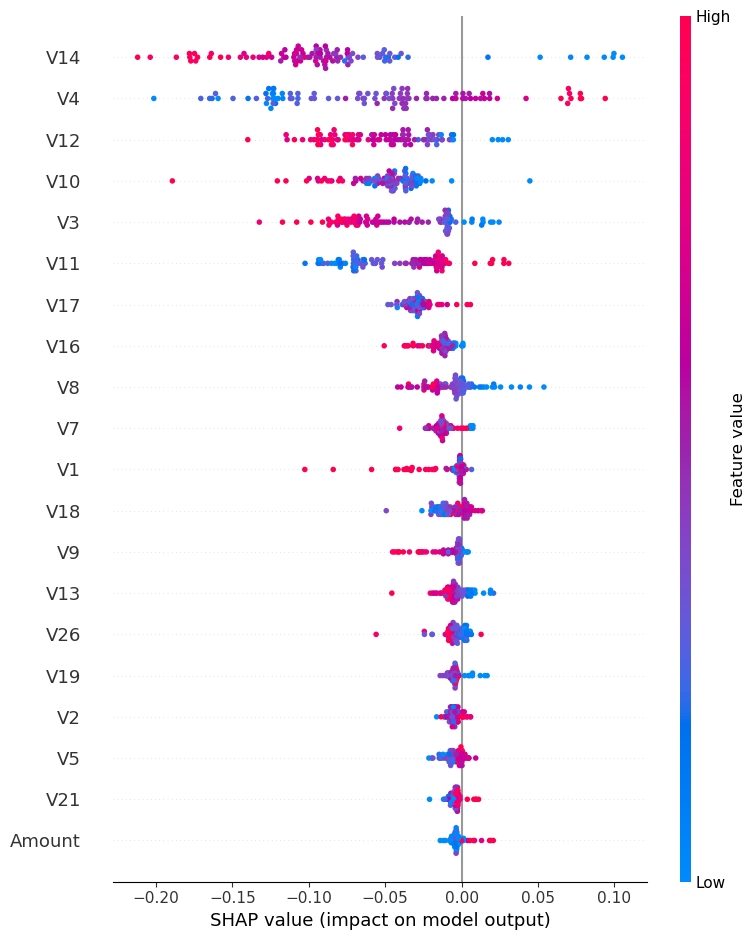

In [14]:
#create a beeswarm plot(Global plot)
shap.summary_plot(final_shap_values, X_sample)

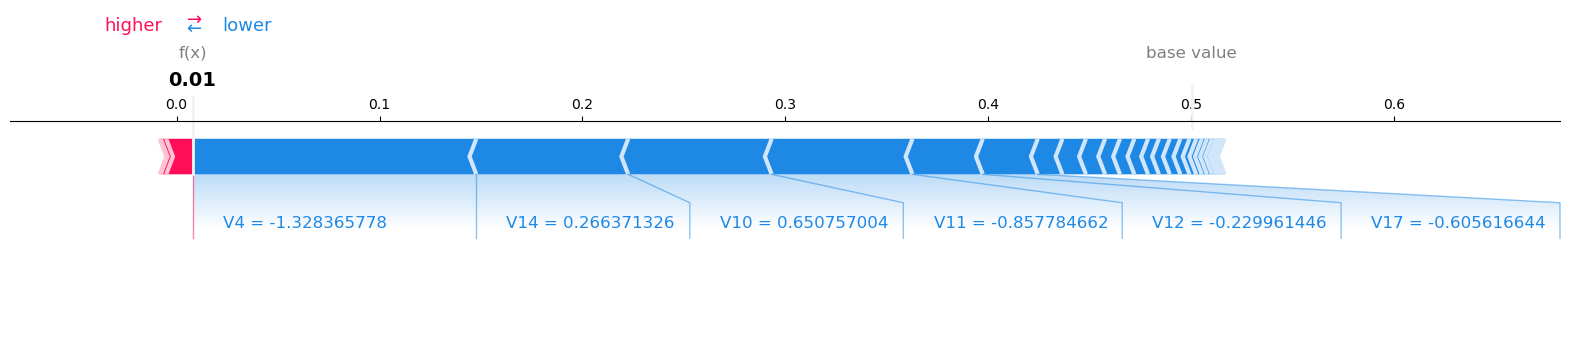

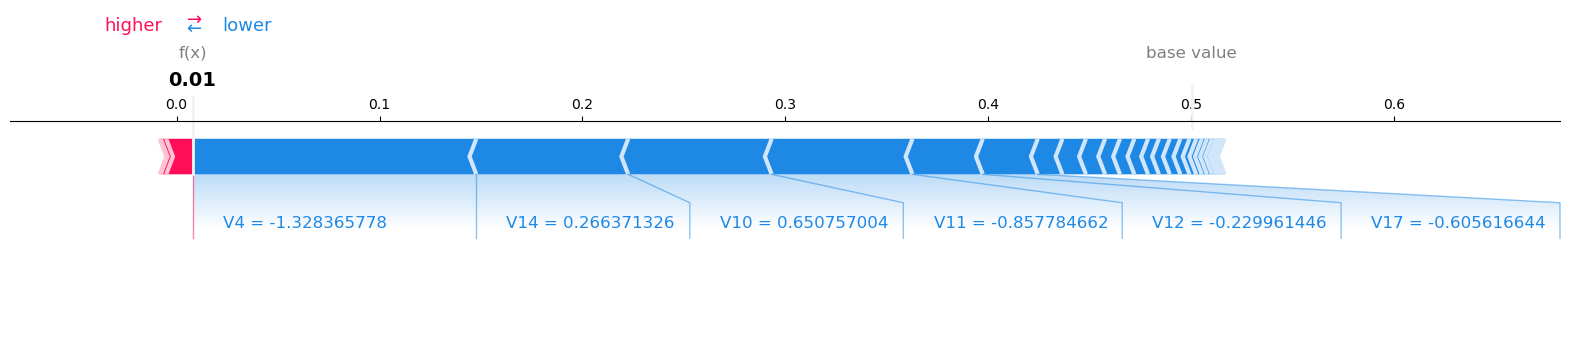

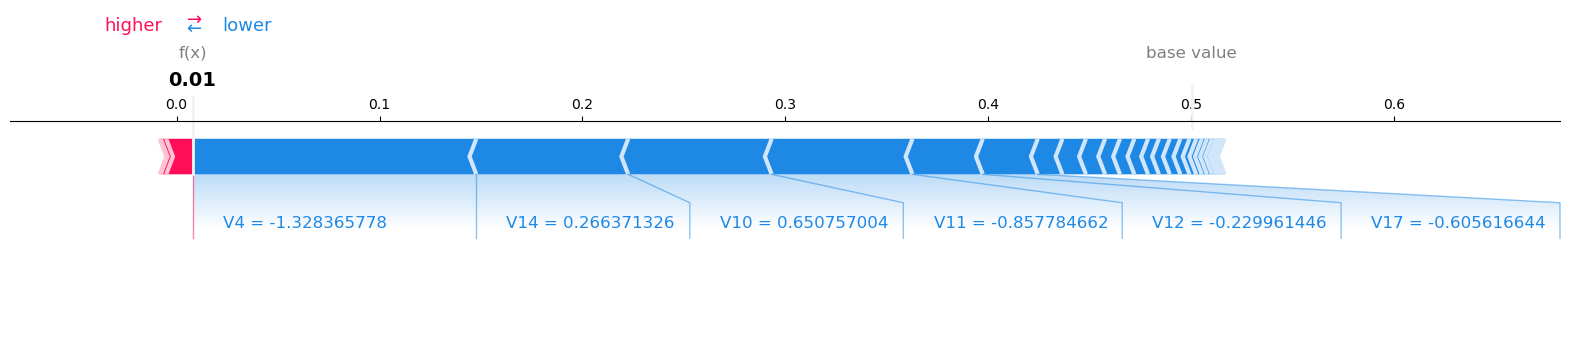

In [19]:
# Force plot using matplotlib=True so it can be saved as image
shap.force_plot(
    explainer.expected_value[1],
    final_shap_values[0, :],
    X_sample.iloc[0, :],
    matplotlib=True,
    show=False
)
# No dots! Just go straight into the reports folder
plt.savefig('reports/shap_force_plot_fraud.png', dpi=150, bbox_inches='tight')
plt.show()



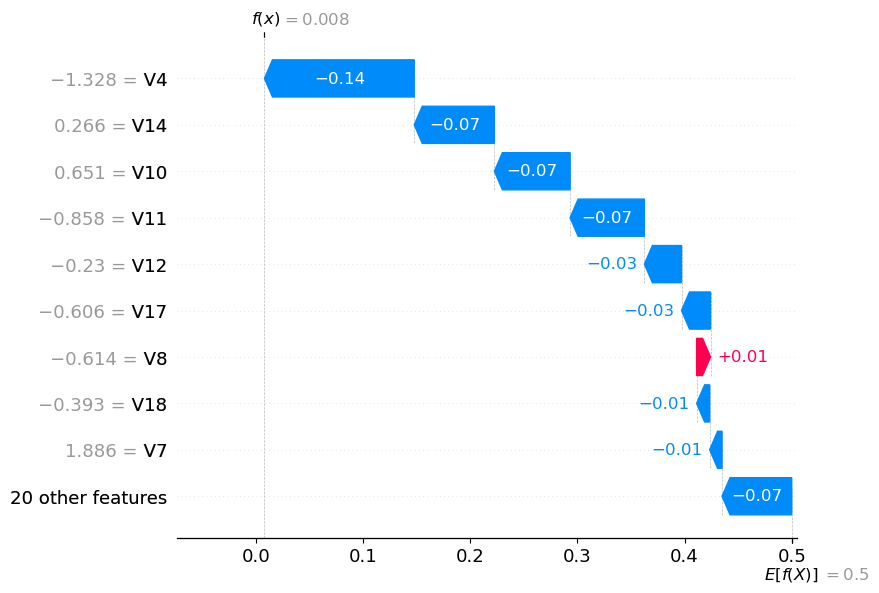

In [20]:
# Plot 3: Waterfall Plot (The Audit Trail) for the first transaction
# We create an 'Explanation' object to format the data for the plot
exp = shap.Explanation(
    values = final_shap_values[0,:],
    base_values = explainer.expected_value[1],
    data = X_sample.iloc[0,:],
    feature_names = X_sample.columns.tolist()

)
shap.plots.waterfall(exp)

In [21]:
import joblib

# This saves the model as a file in your project folder
joblib.dump(model_rf, 'fraud_model.pkl')

# This saves the scaler as a file in your project folder
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']